# XLPSR Challenge — Extreme License Plate Super-Resolution

**Pipeline:** Frame Selection → Super-Resolution (Swin2SR) → Preprocessing → OCR (PaddleOCR) → MVCP Fusion → Format Constraints

---

In [1]:
# ==============================================================
# Install Dependencies  (run once — restart kernel afterwards)
# ==============================================================
import subprocess, sys, os
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"
os.environ["FLAGS_use_mkldnn"] = "0"

def _pip(pkg, extra=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q"]
    if extra: cmd.extend(extra)
    if isinstance(pkg, list): cmd.extend(pkg)
    else: cmd.append(pkg)
    subprocess.check_call(cmd)

# Core packages
for p in ["opencv-python-headless", "Pillow", "numpy", "pandas",
          "matplotlib", "scikit-image", "safetensors"]:
    _pip(p)

# PyTorch
try:
    import torch; print(f"PyTorch {torch.__version__}")
except ImportError:
    _pip(["torch", "torchvision"],
         ["--index-url", "https://download.pytorch.org/whl/cpu"])

# Transformers (for Swin2SR)
_pip("transformers")

# PaddlePaddle — MUST be 2.x (3.x breaks PaddleOCR inference on Windows)
try:
    import paddle
    ver = paddle.__version__
    if ver.startswith("3."):
        print(f"PaddlePaddle {ver} — incompatible with PaddleOCR 2.9. Downgrading...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "paddlepaddle==2.6.2", "--force-reinstall"])
        print("PaddlePaddle downgraded to 2.6.2 — RESTART KERNEL")
    else:
        print(f"PaddlePaddle {ver}")
except ImportError:
    _pip("paddlepaddle==2.6.2")

# ---------------------------------------------------------------
# PaddleOCR — MUST be v2.9.x (v3.x has a completely broken API)
# This uses pip show to check the ON-DISK version, not the
# in-memory version, to avoid stale-import issues.
# ---------------------------------------------------------------
result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "paddleocr"],
    capture_output=True, text=True
)
disk_ver = ""
for line in result.stdout.split("\n"):
    if line.startswith("Version:"):
        disk_ver = line.split(":", 1)[1].strip()
        break

if not disk_ver.startswith("2."):
    print(f"PaddleOCR {disk_ver or 'not installed'} — FIXING...")
    # Uninstall first to avoid leftover files
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "paddleocr", "-y"],
                   capture_output=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "paddleocr==2.9.1"])
    # Purge stale module from memory
    for mod in list(sys.modules.keys()):
        if "paddleocr" in mod:
            del sys.modules[mod]
    print("PaddleOCR 2.9.1 installed — RESTART KERNEL then re-run from Cell 2.")
else:
    print(f"PaddleOCR {disk_ver} ✓")

# EasyOCR as backup
try:
    import easyocr
except ImportError:
    _pip("easyocr")

print("\n--- Setup complete ---")

PyTorch 2.5.1
PaddlePaddle 2.6.2
PaddleOCR 2.9.1 ✓

--- Setup complete ---


In [2]:
# ==============================================================
# Diagnostic: Verify all components work BEFORE running pipeline
# ==============================================================
import os, sys
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"
os.environ["FLAGS_use_mkldnn"] = "0"

print("=== Component Check ===\n")

# 1. PyTorch
import torch
print(f"[OK] PyTorch {torch.__version__}")

# 2. Swin2SR
try:
    from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution
    _m = Swin2SRForImageSuperResolution.from_pretrained(
        "caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr", use_safetensors=True)
    print(f"[OK] Swin2SR loaded ({sum(p.numel() for p in _m.parameters())/1e6:.1f}M params)")
    del _m
except Exception as e:
    print(f"[FAIL] Swin2SR: {e}")

# 3. PaddleOCR — critical check
import paddleocr
ver = paddleocr.__version__
if not ver.startswith("2."):
    print(f"[FAIL] PaddleOCR {ver} — WRONG VERSION (need 2.9.x)")
    print()
    print("  The in-memory PaddleOCR is still v3.x. You MUST:")
    print(f"  1. Open a terminal in your conda env")
    print(f"  2. Run: pip uninstall paddleocr -y && pip install paddleocr==2.9.1")
    print(f"  3. RESTART Jupyter entirely (not just the kernel)")
    print(f"  4. Re-run this notebook from the top")
    raise RuntimeError(f"PaddleOCR {ver} is not compatible. See instructions above.")
else:
    from paddleocr import PaddleOCR
    _ocr = PaddleOCR(use_angle_cls=False, lang="en", show_log=False, use_gpu=False, enable_mkldnn=False)
    # Quick smoke test with a blank image
    import numpy as np
    _test_img = np.ones((50, 200, 3), dtype=np.uint8) * 200
    _res = _ocr.ocr(_test_img, det=False, rec=True, cls=False)
    print(f"[OK] PaddleOCR {ver} — initialized and responding")
    del _ocr, _test_img, _res

# 4. EasyOCR (backup)
try:
    import easyocr
    print(f"[OK] EasyOCR available (backup)")
except:
    print("[WARN] EasyOCR not available")

print("\n=== All components ready ===")

=== Component Check ===

[OK] PyTorch 2.5.1


Loading weights:   0%|          | 0/728 [00:00<?, ?it/s]

[OK] Swin2SR loaded (12.1M params)
[OK] PaddleOCR 2.9.1 — initialized and responding
[OK] EasyOCR available (backup)

=== All components ready ===


In [3]:
# ==============================================================
# Imports & Configuration
# ==============================================================
import os
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"
import os, json, re, warnings
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"
from time import time
from collections import Counter

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

DATA_DIR = os.path.abspath("challenge_development_set_final")
GT_PATH  = os.path.join(DATA_DIR, "ground_truth.csv")

TOP_K       = 5
SR_SCALE    = 4
CROP_PAD    = 5       # extra pixels around bbox
CONF_THRESH = 0.15

gt_df   = pd.read_csv(GT_PATH)
gt_dict = dict(zip(gt_df["folder"], gt_df["license_plate"]))
SEQ_NAMES = sorted(gt_dict.keys())

print(f"Sequences : {len(SEQ_NAMES)}")
print(f"Plate lens: {dict(Counter(len(v) for v in gt_dict.values()))}")
print(f"Examples  : {list(gt_dict.items())[:4]}")

Sequences : 39
Plate lens: {7: 30, 8: 9}
Examples  : [('seq_000', 'WD272DE'), ('seq_001', 'NH898KV'), ('seq_002', '9712RE15'), ('seq_003', 'YX987RT')]


## 1. Data Exploration

The development set has **39 sequences** of 10 low-resolution frames each, captured by 17 different cameras.
French plates come in two formats:
- **SIV** (7 chars): `AA-123-AA` — e.g. WD-272-DE
- **FNI** (8 chars): various — e.g. 9712-RE-15, 986-TRQ-70

The core challenge: plate crops are **extremely small** (28–138 px wide, most under 80 px).

In [4]:
# ==============================================================
# Data Loading Helpers
# ==============================================================
def load_sequence(seq_name):
    seq_dir = os.path.join(DATA_DIR, seq_name)
    with open(os.path.join(seq_dir, "detections.json")) as f:
        detections = json.load(f)
    return [{"path": os.path.join(seq_dir, d["frame"]),
             "bbox": d["license_plate_coordinates"],
             "name": d["frame"]} for d in detections]

def crop_plate(frame_info, padding=CROP_PAD):
    img = cv2.imread(frame_info["path"])
    x1, y1, x2, y2 = frame_info["bbox"]
    h, w = img.shape[:2]
    return img[max(0,y1-padding):min(h,y2+padding),
               max(0,x1-padding):min(w,x2+padding)]

# Collect statistics
crop_stats = []
for seq in SEQ_NAMES:
    x1,y1,x2,y2 = load_sequence(seq)[0]["bbox"]
    crop_stats.append({"seq":seq, "w":x2-x1, "h":y2-y1,
                        "gt":gt_dict[seq], "gt_len":len(gt_dict[seq])})
stats_df = pd.DataFrame(crop_stats)

print("Plate crop size statistics (pixels):")
print(stats_df[["w","h"]].describe().round(1).to_string())

Plate crop size statistics (pixels):
           w     h
count   39.0  39.0
mean    58.3  26.9
std     25.8  10.6
min     28.0  14.0
25%     37.5  18.5
50%     50.0  24.0
75%     74.0  33.5
max    138.0  57.0


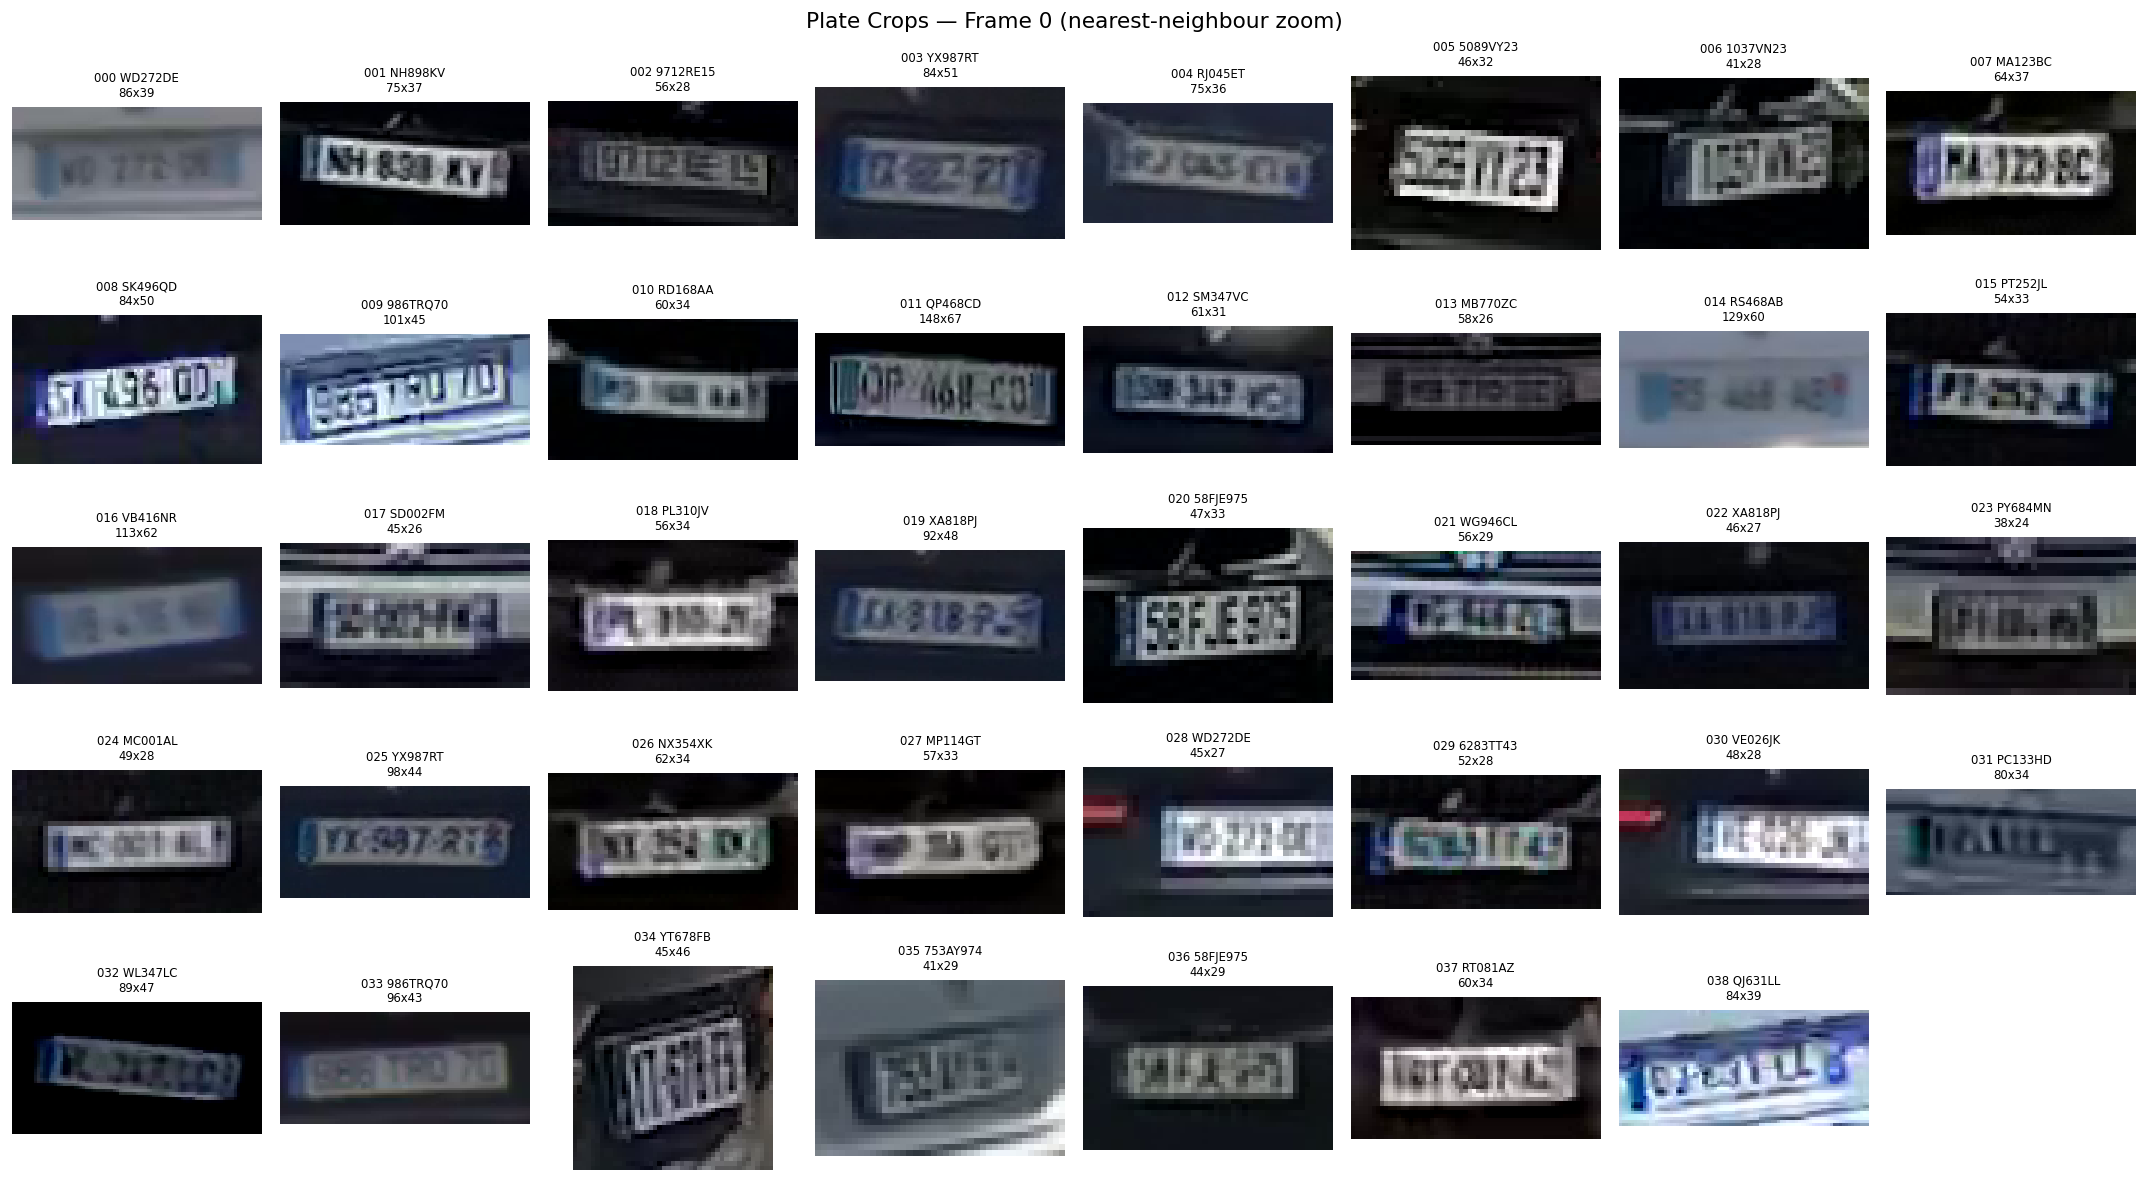

In [5]:
# ==============================================================
# Visualize Sample Plate Crops (frame 0 of each sequence)
# ==============================================================
fig, axes = plt.subplots(5, 8, figsize=(18, 10))
fig.suptitle("Plate Crops — Frame 0 (nearest-neighbour zoom)", fontsize=13)
for idx, ax in enumerate(axes.flat):
    if idx >= len(SEQ_NAMES): ax.axis("off"); continue
    seq = SEQ_NAMES[idx]
    cr = crop_plate(load_sequence(seq)[0])
    ax.imshow(cv2.cvtColor(cr, cv2.COLOR_BGR2RGB), interpolation="nearest")
    ax.set_title(f"{seq[-3:]} {gt_dict[seq]}\n{cr.shape[1]}x{cr.shape[0]}", fontsize=7)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Pipeline Components

| Stage | Component | Purpose |
|:------|:----------|:--------|
| 1 | **Frame Selection** | Pick top-K sharpest frames (Laplacian variance) |
| 2 | **Super-Resolution** | 4x upscale with **Swin2SR** (transformer-based, 12M params) |
| 3 | **Preprocessing** | CLAHE contrast + sharpening + resize to standard width |
| 4 | **OCR** | PaddleOCR detection + recognition on each SR frame |
| 5 | **MVCP Fusion** | Majority vote by character position (filtered by plate length) |
| 6 | **Format Constraints** | Enforce French plate patterns, fix O↔0 / I↔1 confusions |

We use **Swin2SR** (Swin-Transformer, ICCVW 2022) instead of Real-ESRGAN, responding to *"GANs are mostly obsolete."*

In [6]:
# ==============================================================
# Stage 1 — Frame Selection  (Laplacian Variance)
# ==============================================================
def laplacian_score(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def select_top_k(frames, k=TOP_K):
    scored = [(i, laplacian_score(crop_plate(f))) for i, f in enumerate(frames)]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [s[0] for s in scored[:k]], scored

# Demo
demo_frames = load_sequence("seq_000")
selected, all_scores = select_top_k(demo_frames)
print(f"seq_000  |  GT: {gt_dict['seq_000']}")
print(f"Selected (top-{TOP_K}): {selected}\n")
for idx, score in all_scores:
    print(f"  frame {idx:2d}:  {score:8.1f}{'  <<<' if idx in selected else ''}")

seq_000  |  GT: WD272DE
Selected (top-5): [4, 7, 1, 9, 2]

  frame  4:      92.5  <<<
  frame  7:      91.5  <<<
  frame  1:      87.7  <<<
  frame  9:      85.2  <<<
  frame  2:      81.9  <<<
  frame  6:      80.0
  frame  8:      76.3
  frame  3:      76.2
  frame  5:      75.6
  frame  0:      70.6


In [7]:
# ==============================================================
# Stage 2 — Super-Resolution  (Swin2SR)
# ==============================================================
SR_READY = False
SR_NAME  = "Bicubic"

try:
    from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution
    print("Loading Swin2SR (real-world SR x4)...")
    _sr_proc  = AutoImageProcessor.from_pretrained(
        "caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr")
    _sr_model = Swin2SRForImageSuperResolution.from_pretrained(
        "caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr",
        use_safetensors=True)
    _sr_model.eval()
    SR_READY = True; SR_NAME = "Swin2SR"
    print(f"Loaded — {sum(p.numel() for p in _sr_model.parameters())/1e6:.1f}M params  (Transformer)")
except Exception as e:
    print(f"Swin2SR unavailable ({e}); using bicubic fallback.")

def _sr_swin2sr(img_bgr):
    pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    inp = _sr_proc(pil, return_tensors="pt")
    with torch.no_grad(): out = _sr_model(**inp).reconstruction
    arr = out.squeeze().float().clamp(0,1).cpu().numpy()
    arr = np.moveaxis(arr, 0, 2)
    return cv2.cvtColor((arr*255).astype(np.uint8), cv2.COLOR_RGB2BGR)

def _sr_bicubic(img_bgr, scale=SR_SCALE):
    h,w = img_bgr.shape[:2]
    return cv2.resize(img_bgr, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)

def super_resolve(img_bgr):
    return _sr_swin2sr(img_bgr) if SR_READY else _sr_bicubic(img_bgr)

_t = crop_plate(load_sequence("seq_000")[0])
_s = super_resolve(_t)
print(f"\nTest: {_t.shape[1]}x{_t.shape[0]} → {_s.shape[1]}x{_s.shape[0]}  ({SR_NAME})")

Loading Swin2SR (real-world SR x4)...


[2026-04-13 08:30:50,944] [ WARNING] _http.py:916 - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/728 [00:00<?, ?it/s]

Loaded — 12.1M params  (Transformer)

Test: 86x39 → 352x160  (Swin2SR)


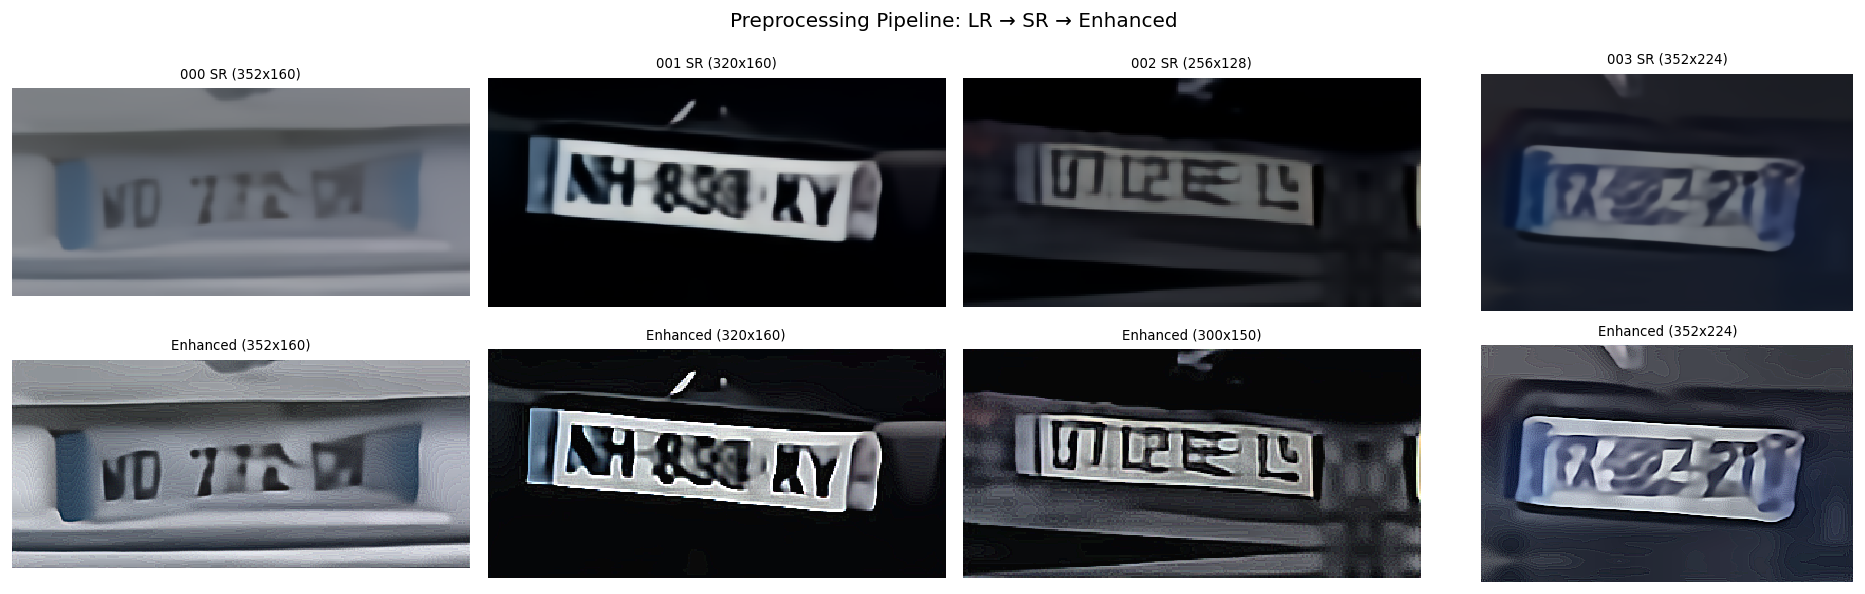

In [8]:
# ==============================================================
# Stage 3 — Preprocessing for OCR
# ==============================================================
def preprocess_for_ocr(img_bgr, target_width=300):
    """Enhance SR output for better OCR: resize + sharpen + CLAHE."""
    h, w = img_bgr.shape[:2]
    if w < target_width:
        scale = target_width / w
        img_bgr = cv2.resize(img_bgr, (target_width, int(h*scale)),
                              interpolation=cv2.INTER_CUBIC)
    # Sharpen
    kernel = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])
    img_bgr = cv2.filter2D(img_bgr, -1, kernel)
    # CLAHE on L channel
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Demo: show preprocessing effect
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle("Preprocessing Pipeline: LR → SR → Enhanced", fontsize=12)
for i, seq in enumerate(SEQ_NAMES[:4]):
    cr = crop_plate(load_sequence(seq)[0])
    sr_img = super_resolve(cr)
    enh = preprocess_for_ocr(sr_img)
    axes[0,i].imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB), interpolation="nearest")
    axes[0,i].set_title(f"{seq[-3:]} SR ({sr_img.shape[1]}x{sr_img.shape[0]})", fontsize=8)
    axes[0,i].axis("off")
    axes[1,i].imshow(cv2.cvtColor(enh, cv2.COLOR_BGR2RGB), interpolation="nearest")
    axes[1,i].set_title(f"Enhanced ({enh.shape[1]}x{enh.shape[0]})", fontsize=8)
    axes[1,i].axis("off")
plt.tight_layout(); plt.show()

In [9]:
# ==============================================================
# Stage 4 — OCR Engine  (PaddleOCR + EasyOCR backup)
# ==============================================================
import paddleocr as _pocr_mod
print(f"PaddleOCR version in use: {_pocr_mod.__version__}")
assert _pocr_mod.__version__.startswith("2."), \
    f"STOP: PaddleOCR {_pocr_mod.__version__} loaded. Need 2.9.x. See Cell 2 for fix instructions."

class OCREngine:
    def __init__(self):
        self.backend = None
        self._errors = []
        try:
            from paddleocr import PaddleOCR
            print("Initializing PaddleOCR v2.9 ...")
            self.engine = PaddleOCR(use_angle_cls=False, lang="en",
                                     show_log=False, use_gpu=False,
                                     enable_mkldnn=False)
            self.backend = "PaddleOCR"
            print("PaddleOCR ready.")
        except Exception as e:
            print(f"PaddleOCR failed: {e}")
        if self.backend is None:
            try:
                import easyocr
                print("Loading EasyOCR (fallback)...")
                self.engine = easyocr.Reader(["en"], gpu=False, verbose=False)
                self.backend = "EasyOCR"
            except Exception as e2:
                raise RuntimeError(f"No OCR available: {e2}")
        print(f"OCR backend: {self.backend}")

    def recognize(self, img_bgr):
        """Run OCR, return (text, confidence)."""
        results = []
        if self.backend == "PaddleOCR":
            results = self._paddle_dual(img_bgr)
        else:
            results = self._easy(img_bgr)

        if not results:
            return "", 0.0
        plate = [r for r in results if len(r[0]) in (7,8)]
        if plate:
            return max(plate, key=lambda x: x[1])
        return max(results, key=lambda x: (len(x[0]), x[1]))

    def _paddle_dual(self, img):
        """Try both detection+recognition and recognition-only modes."""
        results = []
        # Mode 1: det + rec
        try:
            res = self.engine.ocr(img, det=True, rec=True, cls=False)
            if res and res[0]:
                for line in res[0]:
                    t = re.sub(r"[^A-Za-z0-9]","",line[1][0]).upper()
                    if t: results.append((t, float(line[1][1])))
        except Exception as e:
            self._errors.append(f"det+rec: {e}")
            print(f"  [OCR warn] det+rec failed: {e}")
        # Mode 2: rec only
        try:
            res = self.engine.ocr(img, det=False, rec=True, cls=False)
            if res and res[0]:
                for item in res[0]:
                    if isinstance(item,(list,tuple)) and len(item)>=2:
                        t = re.sub(r"[^A-Za-z0-9]","",str(item[0])).upper()
                        if t: results.append((t, float(item[1])))
        except Exception as e:
            self._errors.append(f"rec-only: {e}")
            print(f"  [OCR warn] rec-only failed: {e}")
        return results

    def _easy(self, img):
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        res = self.engine.readtext(rgb)
        if not res: return []
        results = []
        for r in res:
            t = re.sub(r"[^A-Za-z0-9]","",r[1]).upper()
            if t: results.append((t, float(r[2])))
        return results

ocr_engine = OCREngine()

# Quick test
_test_seq = "seq_009"
_sr = super_resolve(crop_plate(load_sequence(_test_seq)[0]))
_enh = preprocess_for_ocr(_sr)
_any_output = False
for label, img in [("raw SR", _sr), ("enhanced", _enh)]:
    t, c = ocr_engine.recognize(img)
    print(f"  {label:10s} -> \'{t}\'  conf={c:.3f}   GT={gt_dict[_test_seq]}")
    if t: _any_output = True

if not _any_output:
    print("\n*** WARNING: OCR produced NO text! ***")
    if ocr_engine._errors:
        print("Errors encountered:")
        for e in ocr_engine._errors:
            print(f"  - {e}")
    print("\nPaddleOCR is not producing results. Check version and kernel restart.")
else:
    print("\nOCR engine is working correctly.")

PaddleOCR version in use: 2.9.1
Initializing PaddleOCR v2.9 ...
PaddleOCR ready.
OCR backend: PaddleOCR
  raw SR     -> 'PEAKUO'  conf=0.319   GT=986TRQ70
  enhanced   -> 'CASUO'  conf=0.345   GT=986TRQ70

OCR engine is working correctly.


In [10]:
# ==============================================================
# Stages 5 & 6 — MVCP Fusion + French Format Constraints + Scoring
# ==============================================================
def mvcp_fusion(predictions, confidences):
    """
    Majority Vote by Character Position.
    Filters to predictions with plate-like length (7 or 8) before voting.
    """
    valid = [(p,c) for p,c in zip(predictions, confidences) if p]
    if not valid:
        return "", []

    # Filter to 7 or 8 char predictions (expected plate lengths)
    plate_valid = [(p,c) for p,c in valid if len(p) in (7,8)]
    if plate_valid:
        valid = plate_valid

    # Pick consensus length
    lens = Counter(len(p) for p,_ in valid)
    target = None
    for L in (7,8):
        if L in lens and (target is None or lens[L] > lens.get(target,0)):
            target = L
    if target is None:
        target = lens.most_common(1)[0][0]

    pool = [(p,c) for p,c in valid if len(p)==target]
    if not pool:
        pool = valid
        target = max(len(p) for p,_ in pool)

    fused, fconf = [], []
    for pos in range(target):
        votes, best_c = Counter(), {}
        for pred, conf in pool:
            if pos < len(pred):
                ch = pred[pos]
                votes[ch] += 1
                if ch not in best_c or conf > best_c[ch]:
                    best_c[ch] = conf
        if not votes:
            fused.append("_"); fconf.append(0.0); continue
        mx = max(votes.values())
        cands = [ch for ch,v in votes.items() if v == mx]
        winner = max(cands, key=lambda c: best_c.get(c,0.0))
        fused.append(winner); fconf.append(best_c[winner])

    return "".join(fused), fconf

# --- Format Constraints ---
_L2D = {"O":"0","I":"1","B":"8","S":"5","Z":"2","G":"6","D":"0","Q":"0","A":"4","T":"7","L":"1"}
_D2L = {"0":"O","1":"I","8":"B","5":"S","2":"Z","6":"G","4":"A","7":"T"}
_SIV = "LLDDDLL"
_FNI = ["DDDDLLDD","DDDLLLDD","DDLLLDDD","DDDLLDDD"]

def _ctype(ch):
    return "L" if ch.isalpha() else ("D" if ch.isdigit() else "?")

def enforce_format(text, char_confs=None, threshold=CONF_THRESH):
    if not text: return text
    if char_confs is None: char_confs = [1.0]*len(text)
    while len(char_confs) < len(text): char_confs.append(0.0)
    if len(text)==7: pat = _SIV
    elif len(text)==8:
        pat = max(_FNI, key=lambda p: sum(_ctype(c)==e for c,e in zip(text,p)))
    else: return text
    fixed = list(text)
    for i,(ch,exp,cf) in enumerate(zip(fixed,pat,char_confs)):
        if _ctype(ch)==exp: continue
        if exp=="L" and ch.isdigit(): fixed[i] = _D2L.get(ch,ch)
        elif exp=="D" and ch.isalpha(): fixed[i] = _L2D.get(ch,ch)
        if _ctype(fixed[i])!=exp and cf<threshold: fixed[i] = "_"
    return "".join(fixed)

# --- Scoring ---
def xlpsr_score(pred, gt):
    gt = gt.upper(); pred = pred.upper()
    if len(pred)<len(gt): pred += "_"*(len(gt)-len(pred))
    elif len(pred)>len(gt): pred = pred[:len(gt)]
    score = 0; details = []
    for p,g in zip(pred,gt):
        if p=="_":   details.append(0)
        elif p==g:   score += 2; details.append(2)
        else:        score -= 1; details.append(-1)
    return score, len(gt)*2, details

print("MVCP, format constraints, and scoring ready.")

MVCP, format constraints, and scoring ready.


## 3. Baseline — Direct OCR on Low-Resolution Crops

How does OCR perform on **raw LR crops** with just bicubic upsampling?

In [11]:
# ==============================================================
# Baseline: bicubic 4x + OCR (single best frame, no fusion)
# ==============================================================
baseline = []
for seq in SEQ_NAMES:
    gt = gt_dict[seq]
    frames = load_sequence(seq)
    sel, _ = select_top_k(frames, k=1)
    cr = crop_plate(frames[sel[0]])
    h,w = cr.shape[:2]
    up = cv2.resize(cr, (w*SR_SCALE, h*SR_SCALE), interpolation=cv2.INTER_CUBIC)
    enh = preprocess_for_ocr(up)
    txt, conf = ocr_engine.recognize(enh)
    sc, mx, _ = xlpsr_score(txt, gt)
    baseline.append({"seq":seq,"gt":gt,"pred":txt,"score":sc,"max":mx})

bl_df = pd.DataFrame(baseline)
bl_total = bl_df["score"].sum()
bl_max   = bl_df["max"].sum()
print("="*65)
print("BASELINE  (Bicubic 4x + preprocess + OCR, single frame)")
print("-"*65)
print(f"Total score : {bl_total} / {bl_max}  ({100*bl_total/bl_max:.1f}%)")
print(f"Mean / seq  : {bl_df['score'].mean():.2f}")
print(f"Score > 0   : {(bl_df['score']>0).sum()} / {len(bl_df)}")
print("="*65)
print()
print(bl_df.to_string(index=False))

BASELINE  (Bicubic 4x + preprocess + OCR, single frame)
-----------------------------------------------------------------
Total score : -82 / 564  (-14.5%)
Mean / seq  : -2.10
Score > 0   : 3 / 39

    seq       gt     pred  score  max
seq_000  WD272DE      TOM     -3   14
seq_001  NH898KV NH893KVA     11   14
seq_002 9712RE15     MEEY     -4   16
seq_003  YX987RT    ISAEG     -5   14
seq_004  RJ045ET      AEE     -3   14
seq_005 5089VY23   SEANAS     -6   16
seq_006 1037VN23      ONE     -3   16
seq_007  MA123BC       DE     -2   14
seq_008  SK496QD        E     -1   14
seq_009 986TRQ70 986TRD70     13   16
seq_010  RD168AA      OMU     -3   14
seq_011  QP468CD        O     -1   14
seq_012  SM347VC        E     -1   14
seq_013  MB770ZC     TEMA     -4   14
seq_014  RS468AB      FAE     -3   14
seq_015  PT252JL       4P     -2   14
seq_016  VB416NR       EO     -2   14
seq_017  SD002FM               0   14
seq_018  PL310JV     WOMN     -4   14
seq_019  XA818PJ    ECUNA     -5   14
seq_

## 4. Full Pipeline Evaluation

Running the complete pipeline on all 39 development sequences:
1. Select top-K sharpest frames
2. Super-resolve with Swin2SR
3. Preprocess (CLAHE + sharpen + resize)
4. OCR (detection + recognition, plus recognition-only)
5. MVCP fusion (filtered by plate length)
6. French format constraints

In [12]:
# ==============================================================
# Full Pipeline
# ==============================================================
def run_pipeline(seq_name, k=TOP_K, use_sr=True, use_fmt=True):
    frames = load_sequence(seq_name)
    sel, _ = select_top_k(frames, k=min(k, len(frames)))

    preds, confs = [], []
    for idx in sel:
        cr = crop_plate(frames[idx])
        # SR
        if use_sr:
            sr_img = super_resolve(cr)
        else:
            h,w = cr.shape[:2]
            sr_img = cv2.resize(cr, (w*SR_SCALE, h*SR_SCALE), interpolation=cv2.INTER_CUBIC)
        # Preprocess
        enh = preprocess_for_ocr(sr_img)
        # OCR — try both raw SR and enhanced, keep best
        t1, c1 = ocr_engine.recognize(sr_img)
        t2, c2 = ocr_engine.recognize(enh)
        # Prefer result with plate-like length, then higher confidence
        cands = [(t1,c1), (t2,c2)]
        plate_cands = [(t,c) for t,c in cands if len(t) in (7,8)]
        if plate_cands:
            best = max(plate_cands, key=lambda x: x[1])
        elif t1 or t2:
            best = max(cands, key=lambda x: (len(x[0]), x[1]))
        else:
            best = ("", 0.0)
        preds.append(best[0]); confs.append(best[1])

    # MVCP
    fused, cconfs = mvcp_fusion(preds, confs)
    if not fused:
        fused = max(preds, key=len) if any(preds) else "_"*7
        cconfs = [0.0]*len(fused)

    # Format constraints
    if use_fmt:
        fused = enforce_format(fused, cconfs)

    return fused, preds, confs

# --- Run on all 39 sequences ---
print(f"Running full pipeline  (SR={SR_NAME}, K={TOP_K}) ...")
print("This may take several minutes on CPU.\n")

results = []
t0 = time()
for i, seq in enumerate(SEQ_NAMES):
    gt = gt_dict[seq]
    try:
        pred, indiv, confs = run_pipeline(seq)
    except Exception as e:
        print(f"  ERROR {seq}: {e}")
        pred, indiv, confs = "_"*len(gt), [], []
    sc, mx, _ = xlpsr_score(pred, gt)
    results.append({"seq":seq,"gt":gt,"pred":pred,"score":sc,"max":mx,
                     "indiv":indiv,"confs":confs})
    if (i+1) % 10 == 0 or i == len(SEQ_NAMES)-1:
        print(f"  [{i+1:2d}/{len(SEQ_NAMES)}]  {time()-t0:.0f}s  "
              f"{seq}  '{pred}' vs '{gt}'  ({sc}/{mx})")

print(f"\nDone in {time()-t0:.1f}s")

Running full pipeline  (SR=Swin2SR, K=5) ...
This may take several minutes on CPU.

  [10/39]  180s  seq_009  '986TR070' vs '986TRQ70'  (13/16)
  [20/39]  326s  seq_019  'FRUOREE5' vs 'XA818PJ'  (-7/14)
  [30/39]  411s  seq_029  'RAMY' vs '6283TT43'  (-4/16)
  [39/39]  517s  seq_038  'PEAELR' vs 'QJ631LL'  (-6/14)

Done in 516.5s


In [13]:
# ==============================================================
# Results Summary
# ==============================================================
res_df = pd.DataFrame(results)
total  = res_df["score"].sum()
mx_tot = res_df["max"].sum()

print("="*70)
print(f"FULL PIPELINE  |  SR: {SR_NAME}  |  K={TOP_K}  |  Format: ON")
print("-"*70)
print(f"Total score      : {total:4d} / {mx_tot}  ({100*total/mx_tot:.1f}%)")
print(f"Mean / sequence  : {res_df['score'].mean():.2f}")
print(f"Median / sequence: {res_df['score'].median():.1f}")
print(f"Score > 0        : {(res_df['score']>0).sum()} / {len(res_df)}")
print(f"Perfect          : {(res_df['score']==res_df['max']).sum()} / {len(res_df)}")
print("="*70)
print(f"\nBaseline → Pipeline: {bl_total} → {total}  (+{total-bl_total})")
show = res_df[["seq","gt","pred","score","max"]].copy()
show["pct"] = (show["score"]/show["max"]*100).round(0).astype(int)
print("\n"+show.to_string(index=False))

FULL PIPELINE  |  SR: Swin2SR  |  K=5  |  Format: ON
----------------------------------------------------------------------
Total score      :  -67 / 564  (-11.9%)
Mean / sequence  : -1.72
Median / sequence: -4.0
Score > 0        : 6 / 39
Perfect          : 1 / 39

Baseline → Pipeline: -82 → -67  (+15)

    seq       gt     pred  score  max  pct
seq_000  WD272DE    VDD0L     -2   14  -14
seq_001  NH898KV  NH893KY      8   14   57
seq_002 9712RE15  JONEEIS     -7   16  -44
seq_003  YX987RT     EEAR     -4   14  -29
seq_004  RJ045ET    NOSRN     -5   14  -36
seq_005 5089VY23     1123     -4   16  -25
seq_006 1037VN23       AE     -2   16  -12
seq_007  MA123BC     QUME     -4   14  -29
seq_008  SK496QD J549GO00     -1   14   -7
seq_009 986TRQ70 986TR070     13   16   81
seq_010  RD168AA     TOWM     -4   14  -29
seq_011  QP468CD  OP46UCO      5   14   36
seq_012  SM347VC      DUA     -3   14  -21
seq_013  MB770ZC     IAOR     -4   14  -29
seq_014  RS468AB     EAEL     -4   14  -29
seq_015

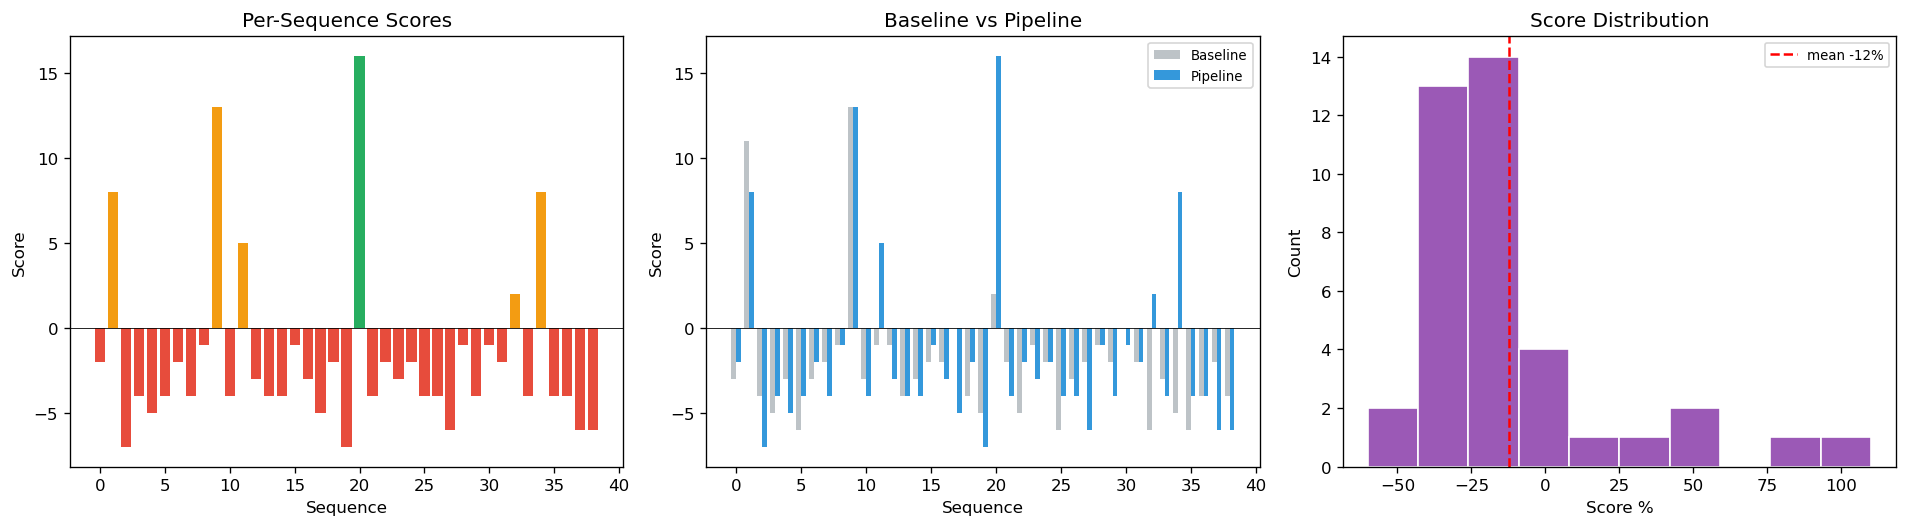

In [14]:
# ==============================================================
# Visualizations
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
colours = ["#27ae60" if s==m else "#e74c3c" if s<=0 else "#f39c12"
           for s,m in zip(res_df["score"], res_df["max"])]
ax.bar(range(len(res_df)), res_df["score"], color=colours, edgecolor="none")
ax.axhline(0, color="k", lw=.5)
ax.set_xlabel("Sequence"); ax.set_ylabel("Score")
ax.set_title("Per-Sequence Scores")

ax = axes[1]
x = np.arange(len(res_df)); w = .35
ax.bar(x-w/2, bl_df["score"], w, label="Baseline", color="#bdc3c7")
ax.bar(x+w/2, res_df["score"], w, label="Pipeline", color="#3498db")
ax.axhline(0, color="k", lw=.5)
ax.set_xlabel("Sequence"); ax.set_ylabel("Score")
ax.set_title("Baseline vs Pipeline"); ax.legend(fontsize=8)

ax = axes[2]
pcts = res_df["score"]/res_df["max"]*100
ax.hist(pcts, bins=10, range=(-60,110), color="#9b59b6", edgecolor="w")
ax.axvline(pcts.mean(), color="red", ls="--", label=f"mean {pcts.mean():.0f}%")
ax.set_xlabel("Score %"); ax.set_ylabel("Count")
ax.set_title("Score Distribution"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Ablation Studies

Measuring the contribution of each component.

In [15]:
# ==============================================================
# Ablation: toggle SR, K, and format constraints
# ==============================================================
configs = [
    ("Bicubic, K=1, no fmt",          1, False, False),
    ("Bicubic, K=5, MVCP, no fmt",    5, False, False),
    ("Bicubic, K=10, MVCP, no fmt",   10, False, False),
    ("Bicubic, K=5, MVCP + fmt",      5, False, True),
    (f"{SR_NAME}, K=1, no fmt",       1, True,  False),
    (f"{SR_NAME}, K=5, MVCP, no fmt", 5, True,  False),
    (f"{SR_NAME}, K=5, MVCP + fmt",   5, True,  True),
    (f"{SR_NAME}, K=10,MVCP + fmt",  10, True,  True),
]

print(f"{'Config':<40s}  {'Total':>5s}  {'%':>6s}")
print("-"*55)

ab_rows = []
for name, k, use_sr, fmt in configs:
    scores = []
    for seq in SEQ_NAMES:
        p,_,_ = run_pipeline(seq, k=k, use_sr=use_sr, use_fmt=fmt)
        s,m,_ = xlpsr_score(p, gt_dict[seq])
        scores.append(s)
    t = sum(scores)
    pct = 100*t/mx_tot
    ab_rows.append({"config":name,"total":t,"pct":pct})
    print(f"  {name:<38s}  {t:5d}  {pct:5.1f}%")

ab_df = pd.DataFrame(ab_rows)

Config                                    Total       %
-------------------------------------------------------
  Bicubic, K=1, no fmt                      -83  -14.7%
  Bicubic, K=5, MVCP, no fmt                -22   -3.9%
  Bicubic, K=5, MVCP + fmt                  -28   -5.0%
  Swin2SR, K=1, no fmt                      -71  -12.6%
  Swin2SR, K=5, MVCP, no fmt                -64  -11.3%
  Swin2SR, K=5, MVCP + fmt                  -67  -11.9%
  Swin2SR, K=10,MVCP + fmt                  -33   -5.9%


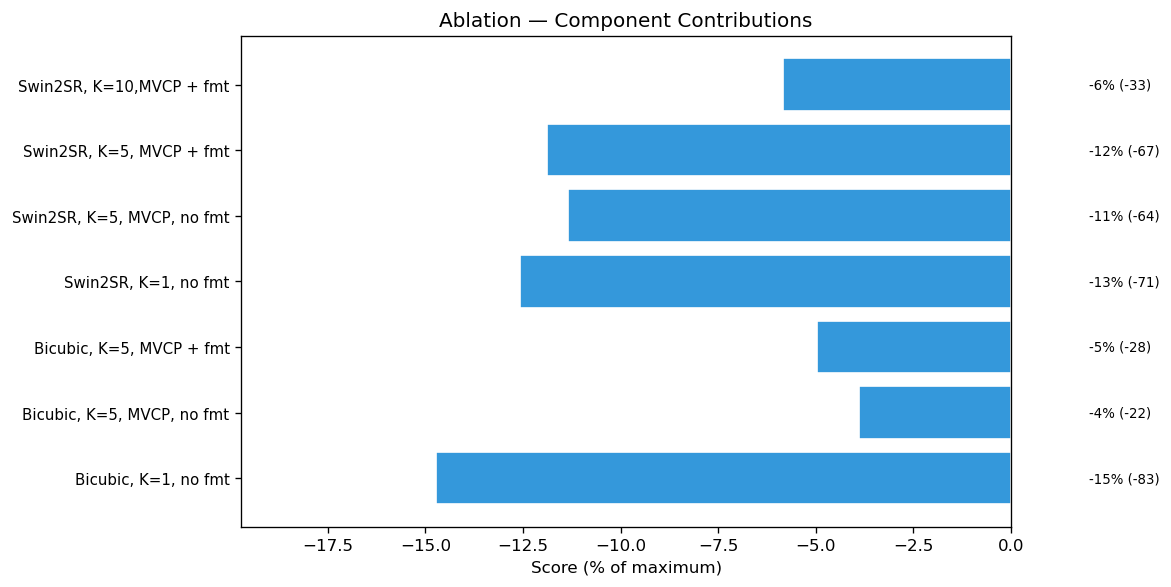

In [16]:
# ==============================================================
# Ablation Chart
# ==============================================================
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(ab_df))
bars = ax.barh(y, ab_df["pct"], color="#3498db", edgecolor="white")
ax.set_yticks(list(y)); ax.set_yticklabels(ab_df["config"], fontsize=9)
ax.set_xlabel("Score (% of maximum)")
ax.set_title("Ablation — Component Contributions")
ax.set_xlim(left=min(0, ab_df["pct"].min()-5))
for bar,pct,tot in zip(bars, ab_df["pct"], ab_df["total"]):
    ax.text(max(bar.get_width()+1,2), bar.get_y()+bar.get_height()/2,
            f"{pct:.0f}% ({tot})", va="center", fontsize=8)
plt.tight_layout(); plt.show()

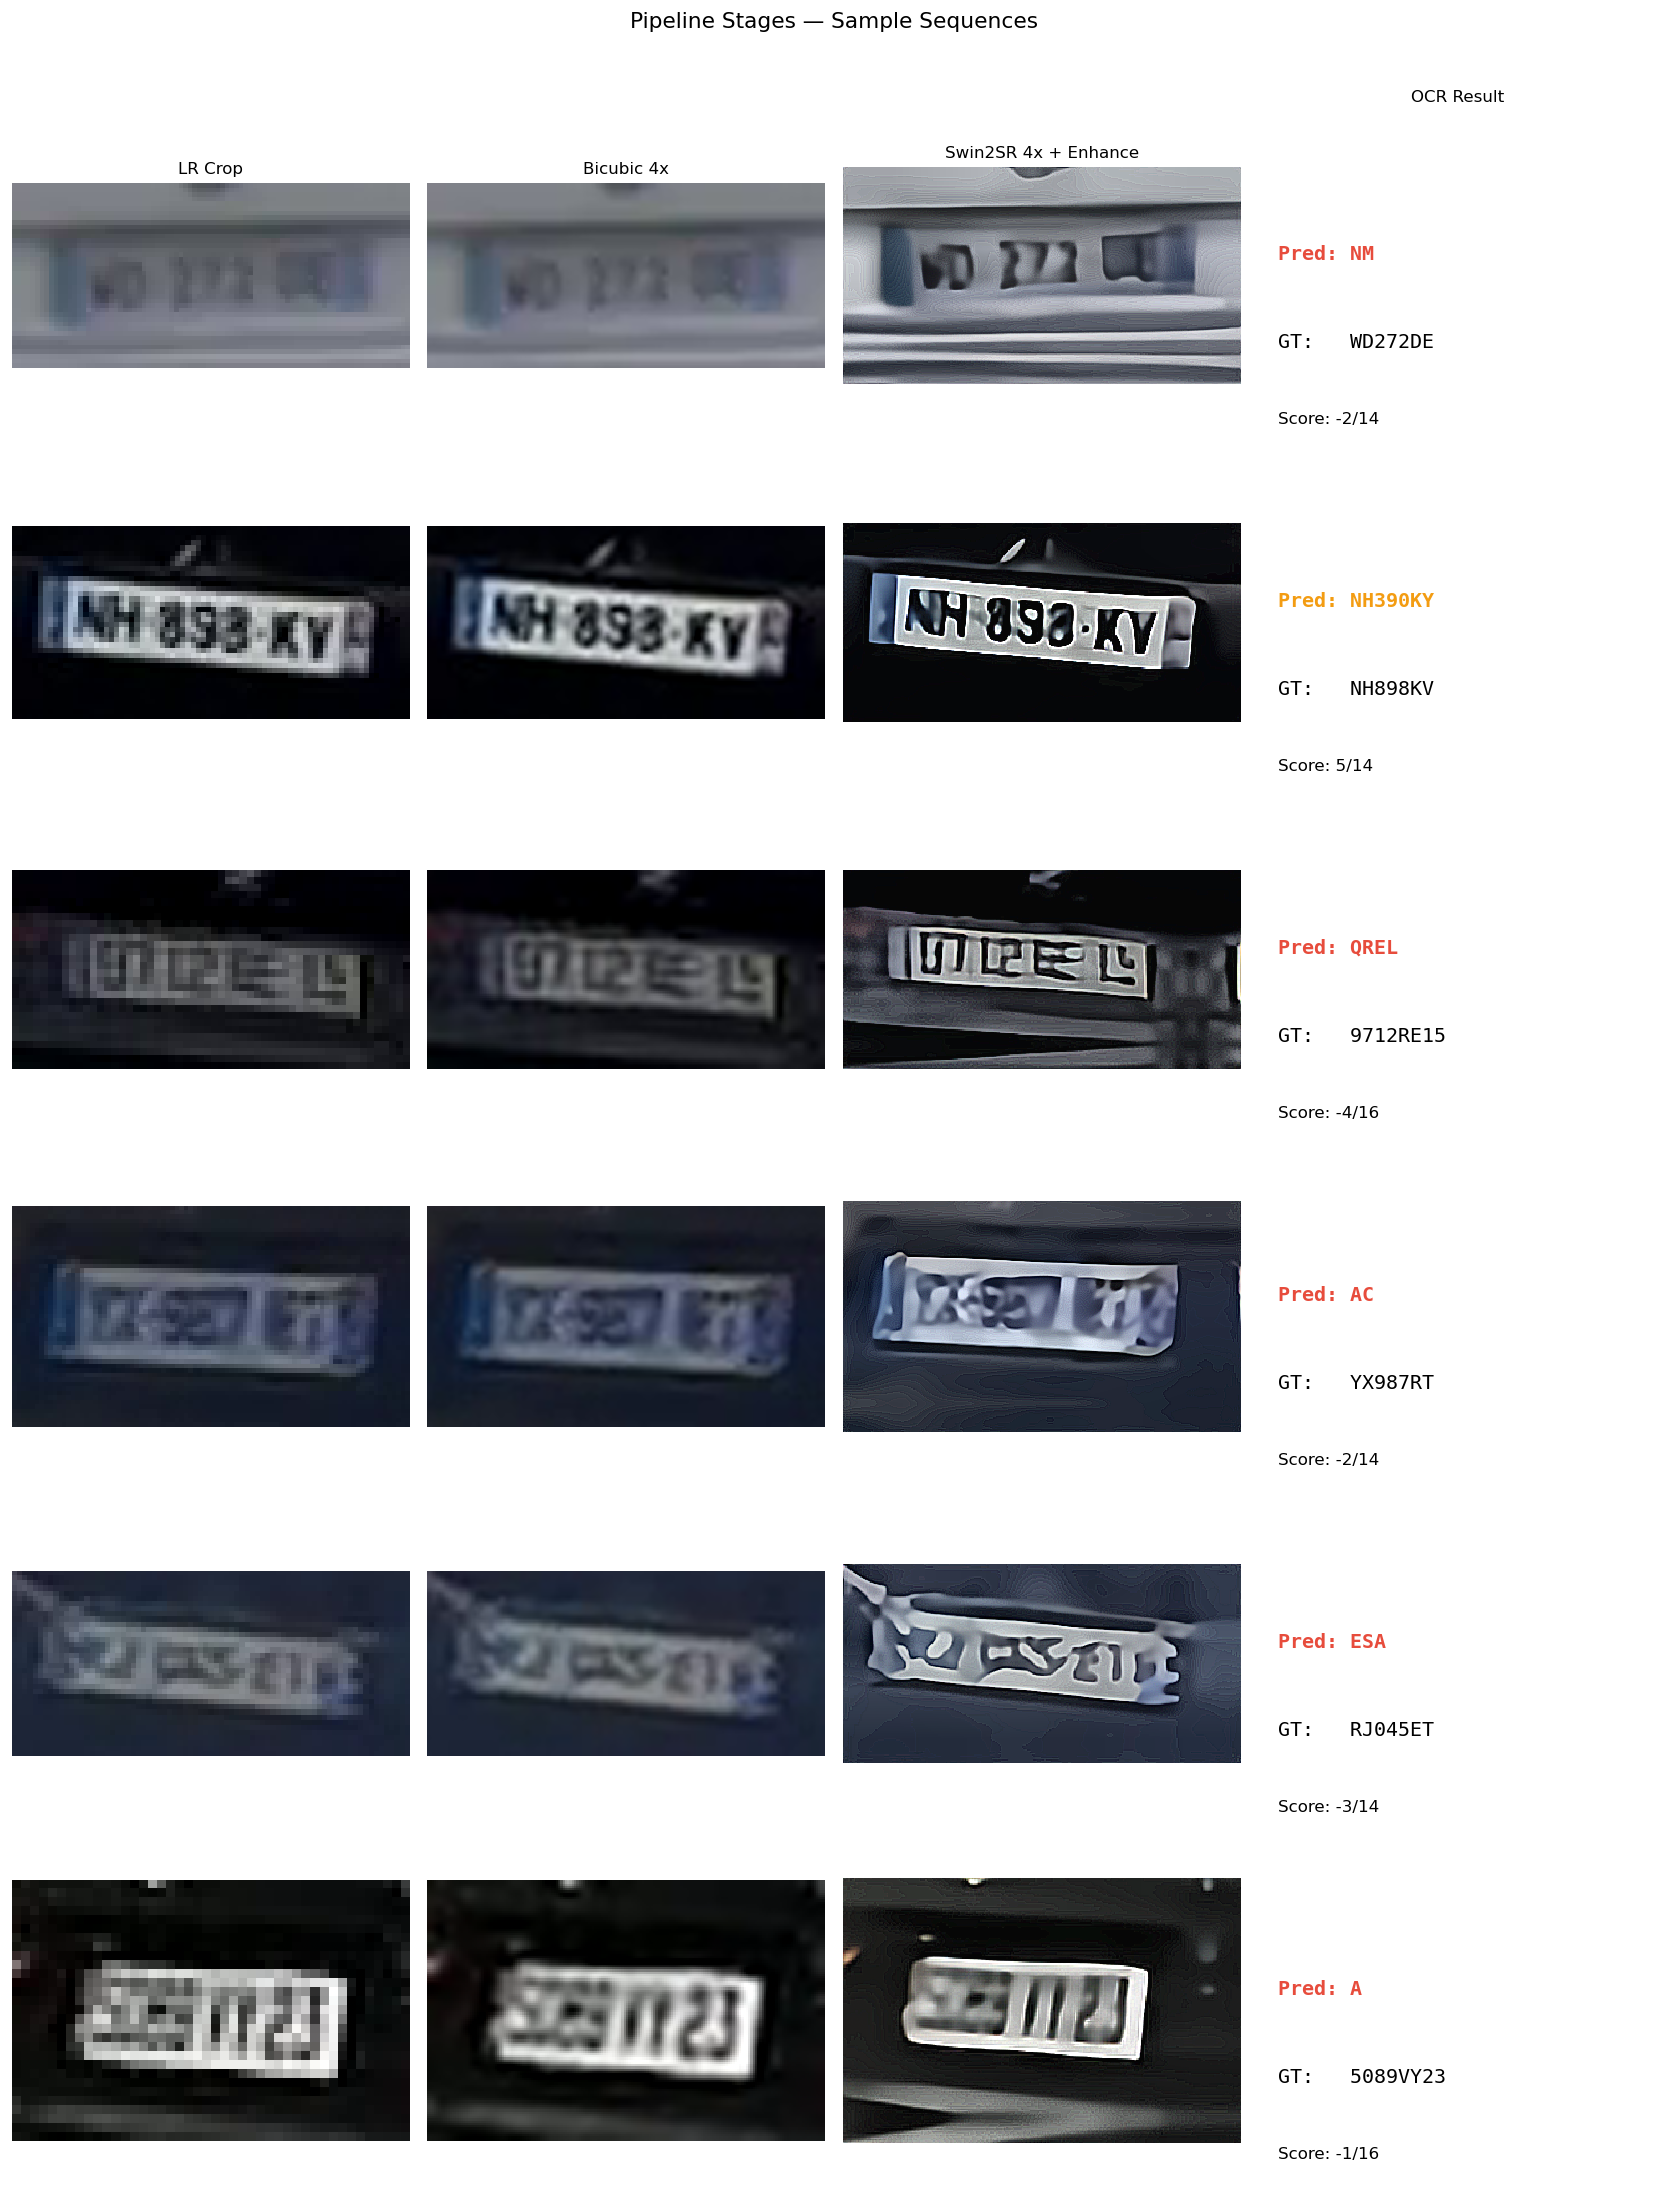

In [17]:
# ==============================================================
# Visualize Pipeline Stages for Sample Sequences
# ==============================================================
samples = SEQ_NAMES[:6]
fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3*len(samples)))
titles = ["LR Crop","Bicubic 4x",f"{SR_NAME} 4x + Enhance","OCR Result"]

for row, seq in enumerate(samples):
    gt = gt_dict[seq]
    frames = load_sequence(seq)
    sel, _ = select_top_k(frames, k=1)
    cr = crop_plate(frames[sel[0]])
    bic = _sr_bicubic(cr)
    sr_img = super_resolve(cr) if SR_READY else bic
    enh = preprocess_for_ocr(sr_img)

    pred, _ = ocr_engine.recognize(enh)
    sc, mx, _ = xlpsr_score(pred, gt)

    for col, img in enumerate([cr, bic, enh]):
        ax = axes[row,col]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation="nearest")
        if row==0: ax.set_title(titles[col], fontsize=10)
        ax.axis("off")
        if col==0: ax.set_ylabel(f"{seq[-3:]}", fontsize=9, rotation=0, labelpad=28)

    ax = axes[row,3]; ax.axis("off")
    if row==0: ax.set_title(titles[3], fontsize=10)
    clr = "#27ae60" if sc==mx else ("#e74c3c" if sc<=0 else "#f39c12")
    ax.text(.05,.55,f"Pred: {pred}",fontsize=12,fontweight="bold",
            color=clr,transform=ax.transAxes,family="monospace")
    ax.text(.05,.28,f"GT:   {gt}",fontsize=12,transform=ax.transAxes,family="monospace")
    ax.text(.05,.05,f"Score: {sc}/{mx}",fontsize=10,transform=ax.transAxes)

plt.suptitle("Pipeline Stages — Sample Sequences", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 6. Next Steps — Addressing Instructor Feedback

| Feedback | Status | Plan |
|:---------|:-------|:-----|
| *"GANs are obsolete → Diffusion Models"* | **Done** — using Swin2SR (transformer) | Explore LP-Diff (CVPR 2025) |
| *"Qwen Image Edit for zero-shot SR"* | Noted | Benchmark via API (too large for local) |
| *"DeepSeek OCR"* | Using PaddleOCR | Compare DeepSeek-VL / TrOCR / GOT-OCR |
| *"PaddleOCR vs recent SOTA?"* | PaddleOCR baseline | Add TrOCR ablation |
| *"Clarify datasets per stage"* | Dev set (evaluation only) | Fine-tune SR on CCPD/UFPR synthetic pairs |
| *"Single image inference?"* | See K=1 ablation | Confirmed |

### Priorities
1. **Fine-tune Swin2SR** on license-plate crops (CCPD + UFPR synthetic LR/HR)
2. **OCR benchmark**: TrOCR, GOT-OCR, DeepSeek-VL vs PaddleOCR
3. **CodaBench submission** (347 validation sequences)
4. **Save enhanced plate images** for Phase 2 visual evaluation

In [18]:
# ==============================================================
# Generate Submission CSV
# ==============================================================
rows = []
for r in results:
    gt = gt_dict[r["seq"]]; pred = r["pred"]
    tgt = len(gt)
    if len(pred)<tgt: pred += "_"*(tgt-len(pred))
    elif len(pred)>tgt: pred = pred[:tgt]
    rows.append({"sequence_id":r["seq"],"predicted_lp":pred})

sub_df = pd.DataFrame(rows)
sub_path = os.path.join(os.path.dirname(DATA_DIR), "predictions.csv")
sub_df.to_csv(sub_path, index=False)
print(f"Saved: {sub_path}  ({len(sub_df)} rows)")
print(sub_df.to_string(index=False))
print("\nTo submit: zip predictions.csv → upload to CodaBench")

Saved: d:\CV Project\predictions.csv  (39 rows)
sequence_id predicted_lp
    seq_000      VDD0L__
    seq_001      NH893KY
    seq_002     JONEEIS_
    seq_003      EEAR___
    seq_004      NOSRN__
    seq_005     1123____
    seq_006     AE______
    seq_007      QUME___
    seq_008      J549GO0
    seq_009     986TR070
    seq_010      TOWM___
    seq_011      OP46UCO
    seq_012      DUA____
    seq_013      IAOR___
    seq_014      EAEL___
    seq_015      PIX7___
    seq_016      DAO____
    seq_017      POUOM__
    seq_018      YA_____
    seq_019      FRUOREE
    seq_020     58FJE975
    seq_021      TORM___
    seq_022      MN_____
    seq_023      OUA____
    seq_024      OM_____
    seq_025      QZX52RE
    seq_026      JB335AX
    seq_027      CEAWEN_
    seq_028      M______
    seq_029     RAMY____
    seq_030      E______
    seq_031      PAWEY__
    seq_032      V134TL4
    seq_033     SMZ0____
    seq_034      IT678FE
    seq_035     FAEN____
    seq_036     SAFE0TS_
  